In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df= pd.read_csv("Passengers.csv")
df

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


       Month  #Passengers
0    1949-01          112
1    1949-02          118
2    1949-03          132
3    1949-04          129
4    1949-05          121
..       ...          ...
139  1960-08          606
140  1960-09          508
141  1960-10          461
142  1960-11          390
143  1960-12          432

[144 rows x 2 columns]
adf p-value:0.9919
time series is not ststionary(failed to reject H0 


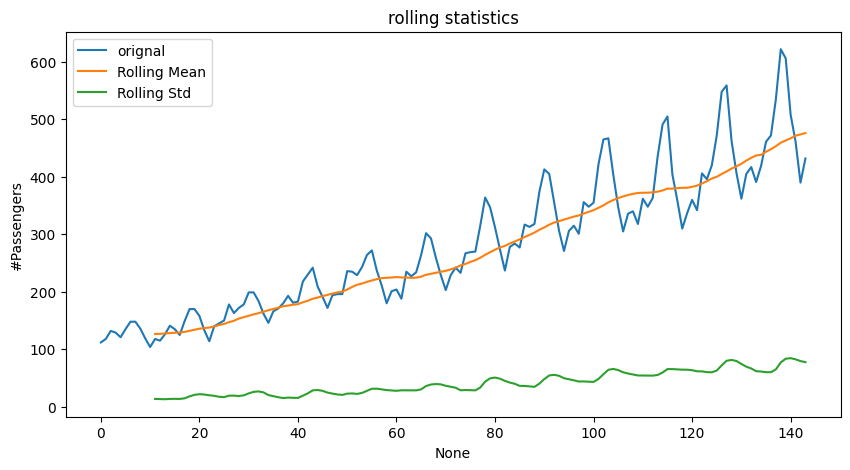

In [3]:
from statsmodels.tsa.stattools import adfuller
import seaborn as sns

airP=df.copy(deep=True)
print(airP)
def test_stationary(dataFrame,var,window=12):
    dataFrame["rollMean"]=dataFrame[var].rolling(window=window).mean()
    dataFrame["rollStd"]=dataFrame[var].rolling(window=window).std()
    adf_result=adfuller(dataFrame[var])
    p_value=adf_result[1]
    print(f"adf p-value:{p_value:.4f}")
    
    if p_value<0.05:
        print("the time series is stationaty(reject H0)")
    else:
        print("time series is not ststionary(failed to reject H0 ")
        plt.figure(figsize=(10,5))
        sns.lineplot(x=dataFrame.index,y=dataFrame[var],label="orignal")
        sns.lineplot(x=dataFrame.index,y=dataFrame["rollMean"],label="Rolling Mean")
        sns.lineplot(x=dataFrame.index,y=dataFrame["rollStd"],label="Rolling Std")
        plt.title("rolling statistics")
        plt.legend()
        plt.show()
test_stationary(airP,'#Passengers')

### test stationarity-SHIFT BY 1

adf p-value:0.9919
time series is not ststionary(failed to reject H0 


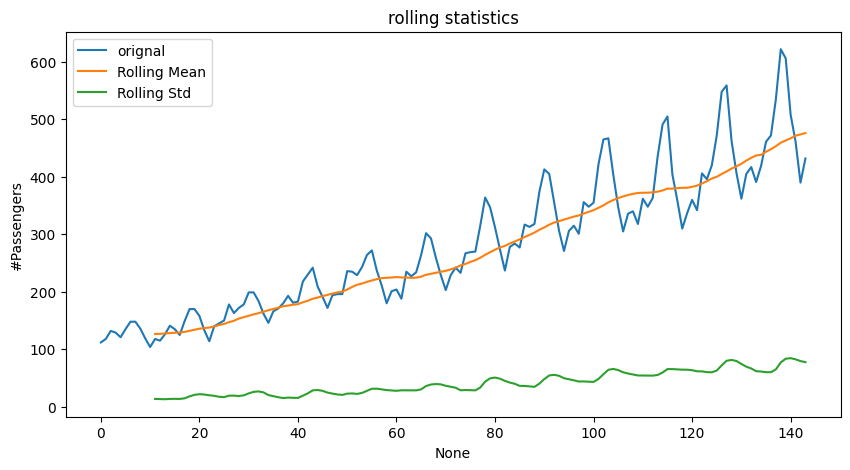

      Month  #Passengers    rollMean    rollStd  shift  shiftDiff
0   1949-01          112         NaN        NaN    NaN        NaN
1   1949-02          118         NaN        NaN  112.0        6.0
2   1949-03          132         NaN        NaN  118.0       14.0
3   1949-04          129         NaN        NaN  132.0       -3.0
4   1949-05          121         NaN        NaN  129.0       -8.0
5   1949-06          135         NaN        NaN  121.0       14.0
6   1949-07          148         NaN        NaN  135.0       13.0
7   1949-08          148         NaN        NaN  148.0        0.0
8   1949-09          136         NaN        NaN  148.0      -12.0
9   1949-10          119         NaN        NaN  136.0      -17.0
10  1949-11          104         NaN        NaN  119.0      -15.0
11  1949-12          118  126.666667  13.720147  104.0       14.0
12  1950-01          115  126.916667  13.453342  118.0       -3.0
13  1950-02          126  127.583333  13.166475  115.0       11.0
14  1950-0

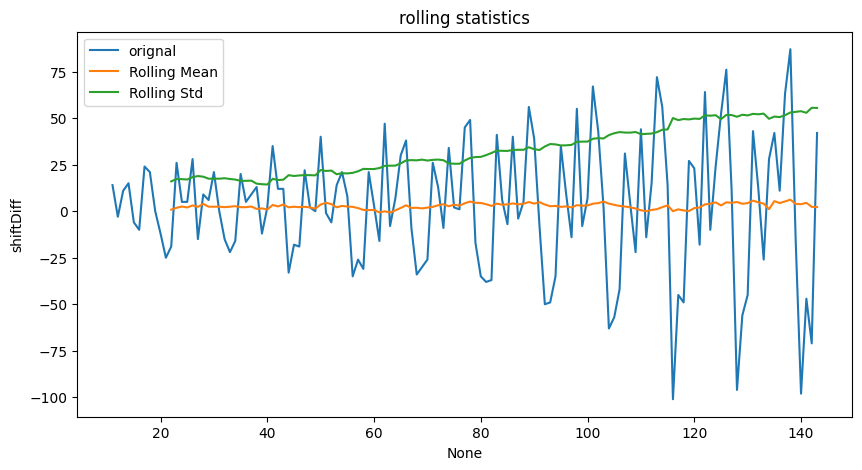

In [4]:
test_stationary(airP,'#Passengers')
# data is not stationary -let us try "diff" method
airP["shift"]=airP['#Passengers'].shift(1)
airP["shiftDiff"]=airP["#Passengers"]-airP["shift"]
print(airP.head(20))
test_stationary(airP.dropna(),"shiftDiff")

###                         test stationarity-SHIFT BY 2

adf p-value:0.9919
time series is not ststionary(failed to reject H0 


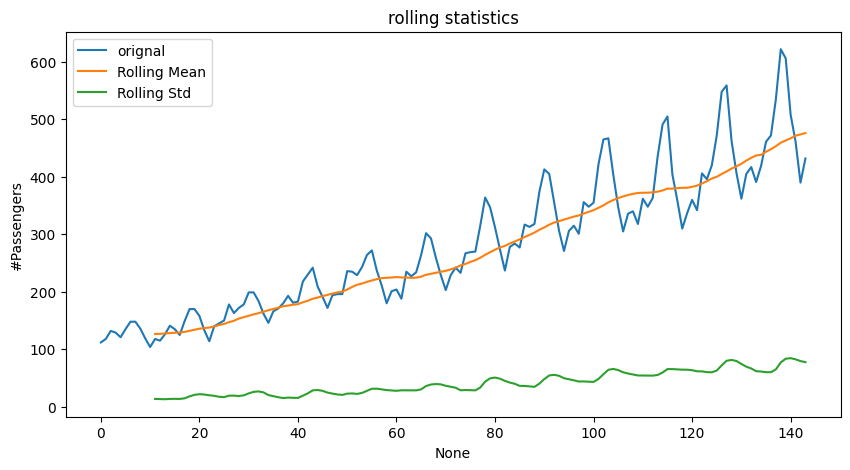

      Month  #Passengers    rollMean    rollStd  shift  shiftDiff
0   1949-01          112         NaN        NaN    NaN        NaN
1   1949-02          118         NaN        NaN    NaN        NaN
2   1949-03          132         NaN        NaN  112.0       20.0
3   1949-04          129         NaN        NaN  118.0       11.0
4   1949-05          121         NaN        NaN  132.0      -11.0
5   1949-06          135         NaN        NaN  129.0        6.0
6   1949-07          148         NaN        NaN  121.0       27.0
7   1949-08          148         NaN        NaN  135.0       13.0
8   1949-09          136         NaN        NaN  148.0      -12.0
9   1949-10          119         NaN        NaN  148.0      -29.0
10  1949-11          104         NaN        NaN  136.0      -32.0
11  1949-12          118  126.666667  13.720147  119.0       -1.0
12  1950-01          115  126.916667  13.453342  104.0       11.0
13  1950-02          126  127.583333  13.166475  118.0        8.0
14  1950-0

In [5]:
test_stationary(airP,'#Passengers')
# data is not stationary -let us try "diff" method
airP["shift"]=airP['#Passengers'].shift(2)
airP["shiftDiff"]=airP["#Passengers"]-airP["shift"]
print(airP.head(20))
test_stationary(airP.dropna(),"shiftDiff")

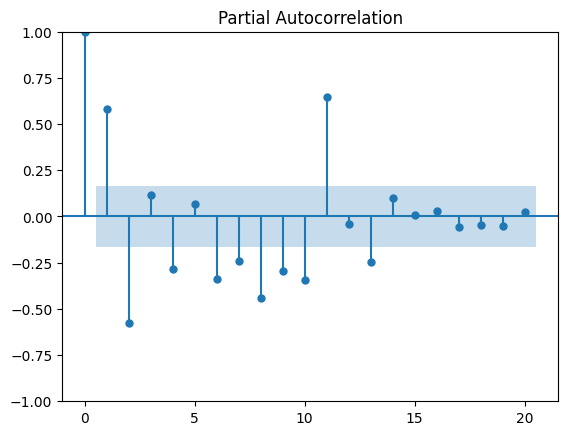

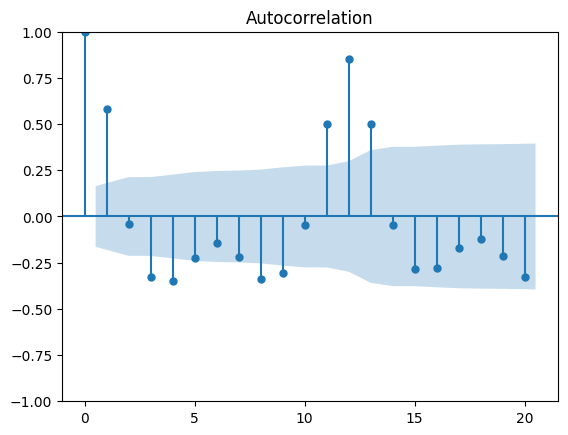

In [6]:
# arima

airP['secondDiff']= airP['#Passengers'].diff(2)
airP['Diff12']= airP['#Passengers'].diff(12)

from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
plot_pacf(airP['secondDiff'].dropna(),lags = 20)
plt.show()

plot_acf(airP['secondDiff'].dropna(),lags = 20)
plt.show()

In [8]:
from statsmodels.tsa.arima.model import ARIMA

# --- STEP 1: SPLIT DATA ---
# We use 70% of the data to train the model and keep 30% to test its accuracy
train_size = int(len(airP) * 0.7)
train = airP.iloc[:train_size]
test = airP.iloc[train_size:]

# --- STEP 2: DEFINE THE MODEL ---
# order=(p, d, q)
# p=1: Looks at 1 lag (AR)
# d=2: Applies differencing twice to make it stationary (I)
# q=1: Looks at 1 error lag (MA)
model_arima = ARIMA(train['#Passengers'], order=(1, 2, 1))

# --- STEP 3: TRAIN THE MODEL ---
# The model 'learns' the patterns from the training data
model_arima_fit = model_arima.fit()

# --- STEP 4: MAKE PREDICTIONS ---
# We ask the model to predict the values for the remaining 30% (the test period)
arima_pred = model_arima_fit.predict(start=len(train), end=len(airP)-1)

# --- STEP 5: STORE RESULTS ---
# Create a blank column for predictions
airP['arimaPred'] = np.nan

# Insert the predicted values into the correct rows (the test set rows)
airP.iloc[train_size:, airP.columns.get_loc('arimaPred')] = arima_pred.values

# Check the results! Compare '#Passengers' (Actual) with 'arimaPred' (Predicted)
print(airP.tail())

       Month  #Passengers    rollMean    rollStd  shift  shiftDiff  \
139  1960-08          606  463.333333  83.630500  535.0       71.0   
140  1960-09          508  467.083333  84.617276  622.0     -114.0   
141  1960-10          461  471.583333  82.541954  606.0     -145.0   
142  1960-11          390  473.916667  79.502382  508.0     -118.0   
143  1960-12          432  476.166667  77.737125  461.0      -29.0   

     secondDiff  Diff12   arimaPred  
139        71.0    47.0  439.708768  
140      -114.0    45.0  442.074513  
141      -145.0    54.0  444.440259  
142      -118.0    28.0  446.806004  
143       -29.0    27.0  449.171750  


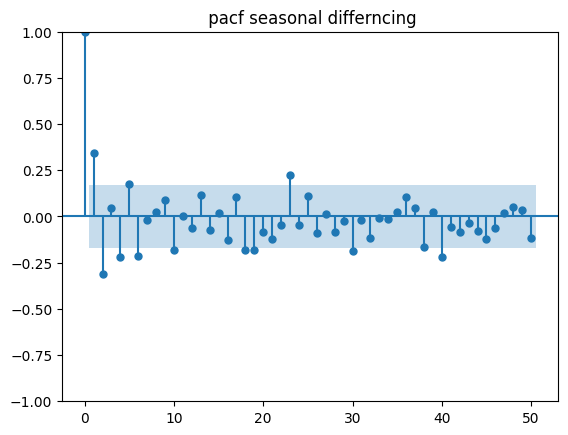

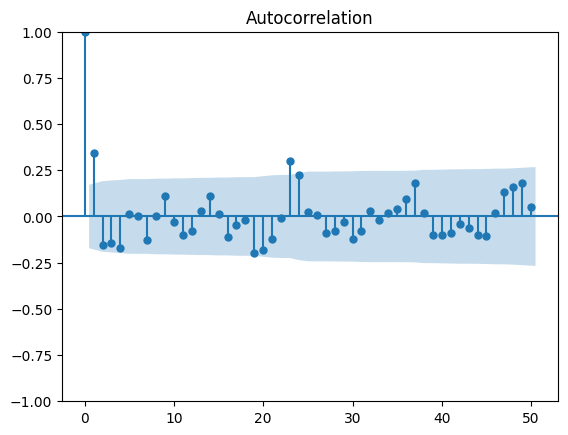

       Month  #Passengers    rollMean    rollStd  shift  shiftDiff  \
124  1959-05          420  397.083333  60.008270  406.0       14.0   
125  1959-06          472  400.166667  63.009138  396.0       76.0   
126  1959-07          548  404.916667  71.987951  420.0      128.0   
127  1959-08          559  409.416667  80.049369  472.0       87.0   
128  1959-09          463  414.333333  81.485451  548.0      -85.0   
129  1959-10          407  418.333333  79.680422  559.0     -152.0   
130  1959-11          362  422.666667  74.498729  463.0     -101.0   
131  1959-12          405  428.333333  69.830097  407.0       -2.0   
132  1960-01          417  433.083333  66.624399  362.0       55.0   
133  1960-02          391  437.166667  61.866180  405.0      -14.0   
134  1960-03          419  438.250000  61.382741  417.0        2.0   
135  1960-04          461  443.666667  60.171472  391.0       70.0   
136  1960-05          472  448.000000  60.184565  419.0       53.0   
137  1960-06        

In [11]:
from statsmodels.tsa.statespace.sarimax import SARIMAX


airP['Diff_combined']= airP['#Passengers'].diff(2).diff(12)

from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
plot_pacf(airP['Diff_combined'].dropna(),lags = 50)
plt.title(" pacf seasonal differncing")
plt.show()

plot_acf(airP['Diff_combined'].dropna(),lags = 50)
plt.show()

model_sarimax = SARIMAX(train['#Passengers'], order=(1, 2, 1))
seasonal_order=(1,2,1,12)
model_sarimax_fit = model_sarimax.fit()
sarimax_pred = model_sarimax_fit.predict(start=len(train), end=len(airP)-1)
airP['sarimaxPred'] = np.nan
airP.iloc[train_size:, airP.columns.get_loc('sarimaxPred')] = sarimax_pred.values
print(airP.tail(20))

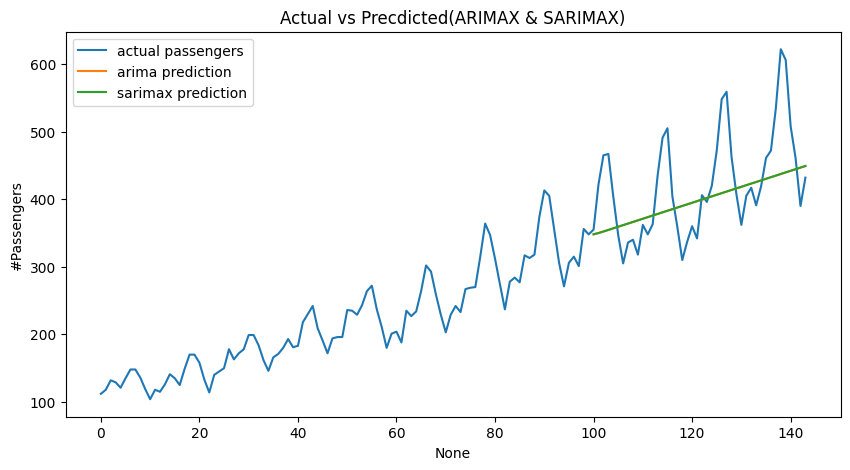

In [12]:
plt.figure(figsize=(10,5))
sns.lineplot(x=airP.index,y=airP["#Passengers"],label="actual passengers")
sns.lineplot(x=airP.index,y=airP["arimaPred"],label="arima prediction")
sns.lineplot(x=airP.index,y=airP["sarimaxPred"],label="sarimax prediction")
plt.title("Actual vs Precdicted(ARIMAX & SARIMAX)")
plt.legend()
plt.show()

1961-01-01    468.930594
1961-02-01    444.067710
1961-03-01    515.025258
1961-04-01    504.546331
1961-05-01    519.272923
1961-06-01    599.658586
1961-07-01    660.643133
1961-08-01    640.478226
1961-09-01    564.491452
1961-10-01    494.154981
1961-11-01    440.992989
1961-12-01    491.735096
1962-01-01    504.316554
1962-02-01    476.354489
1962-03-01    551.715224
1962-04-01    540.280201
1962-05-01    556.585088
1962-06-01    642.032033
1962-07-01    706.534402
1962-08-01    684.276786
1962-09-01    602.452557
1962-10-01    527.354197
1962-11-01    470.623666
1962-12-01    523.908600
Freq: MS, Name: predicted_mean, dtype: float64


C:\Users\PGCP-AI\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\plotting\_matplotlib\core.py:997: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


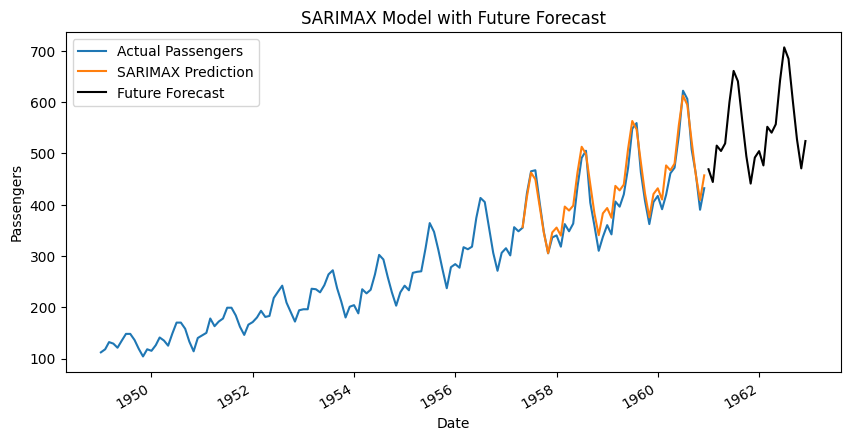

In [17]:
# Step 1: Assign proper datetime index to airP first
airP.index = pd.date_range(start='1949-01-01', periods=len(airP), freq='MS')

# Step 2: Now split (train/test will inherit the datetime index)
train_size = int(len(airP) * 0.7)
train = airP.iloc[:train_size]
test  = airP.iloc[train_size:]

# Step 3: Refit SARIMAX with datetime-indexed train
# You must pass the seasonal_order variable into the function call
model_sarimax = SARIMAX(train['#Passengers'], 
                        order=(1,2,1), 
                        seasonal_order=(1,2,1,12)) 

model_sarimax_fit = model_sarimax.fit()

sarimax_pred = model_sarimax_fit.predict(start=len(train), end=len(airP)-1)
airP['sarimaxPred'] = np.nan
airP.iloc[train_size:, airP.columns.get_loc('sarimaxPred')] = sarimax_pred.values

# Step 4: Future forecast now works with Timestamps
future_forecast = model_sarimax_fit.predict(start='1961-01-01', end='1962-12-01')
print(future_forecast)

# Step 5: Plot
plt.figure(figsize=(10, 5))
sns.lineplot(x=airP.index, y=airP['#Passengers'],   label='Actual Passengers')
sns.lineplot(x=airP.index, y=airP['sarimaxPred'],  label='SARIMAX Prediction')
future_forecast.plot(color='black', label='Future Forecast')
plt.title('SARIMAX Model with Future Forecast')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.show()